In [ ]:
%pip install catboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
#Импорты
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from catboost import CatBoostRegressor
import os


In [2]:
#Загрузка данных
os.chdir('..')
train = pd.read_csv("data/train.csv")
test  = pd.read_csv("data/test.csv")
sub   = pd.read_csv("data/sample_submission.csv")

In [3]:
#Первичный анализ
train.head(5)

,index,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,102.414420,95.757483,0.935000,5.466584,5.466584,0.719259,0.719259,0.681165,18.307692,...,1,0,0,0,0,0,0,0,0,0
1,1,0.044333,8.401080,189.500000,11.492712,11.492712,0.012350,-3.798024,0.769122,27.652174,...,0,1,0,0,0,0,0,0,0,0
2,2,4.437964,50.085589,11.285714,5.366084,5.366084,0.522930,0.522930,0.612606,24.608696,...,0,0,0,0,0,0,0,0,0,0
3,3,6.827881,682.788051,100.000000,13.317130,13.317130,0.020658,-4.829339,0.345823,12.400000,...,0,0,1,0,0,0,0,0,0,0
4,4,2.003253,70.001455,34.943894,6.320833,6.320833,0.300347,0.300347,0.562066,60.272727,...,0,0,0,0,0,0,0,0,0,0


In [4]:
train.describe()

,index,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
count,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,...,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.0,751.000000,751.000000,751.000000
mean,375.000000,204.544021,577.426098,89.153313,10.860070,10.860070,0.180064,-0.971890,0.577938,29.588010,...,0.055925,0.013316,0.010652,0.001332,0.001332,0.054594,0.0,0.069241,0.182423,0.006658
std,216.939316,370.367937,641.515163,788.882198,3.347314,3.347314,0.169163,1.594491,0.214190,12.713195,...,0.272400,0.114699,0.102728,0.036491,0.036491,0.227337,0.0,0.254033,1.227468,0.081377
min,0.000000,0.003517,0.700808,0.011489,2.321942,2.321942,0.000039,-6.992796,0.059567,9.545455,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
25%,187.500000,13.222351,99.998894,1.500000,8.921032,8.921032,0.048473,-1.333831,0.442842,18.306020,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
50%,375.000000,44.069306,376.580899,4.000000,12.197500,12.197500,0.121372,-0.419485,0.636477,29.281250,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
75%,562.500000,206.787402,877.508784,17.372463,13.214245,13.214245,0.290990,0.072488,0.742483,38.875000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
max,750.000000,4095.188563,4538.976189,15620.600000,15.933463,15.933463,1.374614,1.374614,0.947265,60.272727,...,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,1.000000,20.000000,1.000000


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 751 entries, 0 to 750
Columns: 214 entries, index to fr_urea
dtypes: float64(107), int64(107)
memory usage: 1.2 MB


In [6]:
train.columns

Index(['index', 'IC50, mM', 'CC50, mM', 'SI', 'MaxAbsEStateIndex',
       'MaxEStateIndex', 'MinAbsEStateIndex', 'MinEStateIndex', 'qed', 'SPS',
       ...
       'fr_sulfide', 'fr_sulfonamd', 'fr_sulfone', 'fr_term_acetylene',
       'fr_tetrazole', 'fr_thiazole', 'fr_thiocyan', 'fr_thiophene',
       'fr_unbrch_alkane', 'fr_urea'],
      dtype='object', length=214)

In [7]:
print("Пропусков: ", train.isna().sum().sum())

Пропусков:  24


Из первичного анализа тренировочного датасета видно, что данные представлены исключительно числовыми значениями.
Причем некоторые признаки представлены чисто 0 и 1 (уже закодированные категориальные признаки).

Пропусков в данных 24 / (751*214), что меньше 1% - такими пропусками можно пренебречь.

In [8]:
X_train = train.drop(['index', 'IC50, mM', 'CC50, mM', 'SI'], axis=1)

y_ic50 = train['IC50, mM'].values.astype(np.float64)
y_cc50 = train['CC50, mM'].values.astype(np.float64)
y_si   = train['SI'].values.astype(np.float64)

In [9]:
var_series = X_train.var().sort_values()
print("Признаки с низкой дисперсией (< 0.001):")
print(var_series[var_series < 0.001])

Признаки с низкой дисперсией (< 0.001):
NumRadicalElectrons    0.0
SMR_VSA8               0.0
SlogP_VSA9             0.0
fr_thiocyan            0.0
fr_phos_acid           0.0
fr_isothiocyan         0.0
fr_nitroso             0.0
fr_lactam              0.0
fr_benzodiazepine      0.0
fr_diazo               0.0
fr_dihydropyridine     0.0
fr_isocyan             0.0
fr_SH                  0.0
fr_barbitur            0.0
fr_azide               0.0
fr_N_O                 0.0
fr_prisulfonamd        0.0
fr_phos_ester          0.0
dtype: float64


Эти признаки имеют очень низкую вариативность и не дадут значимости для модели - можно удалить.

Бинарные fr_* признаки с редкими фрагментами тоже попадают сюда, но их вклад минимален - в будущем можно рассмотреть их и добавить для улучшения точности модели.

In [10]:
# Записываем сырые таргеты (они критически важны для финального пересчета и графиков)
y_ic50_raw = train['IC50, mM'].values.astype(np.float64)
y_cc50_raw = train['CC50, mM'].values.astype(np.float64)
y_si_raw   = train['SI'].values.astype(np.float64)

# Заполняем пропуски в признаках медианой, чтобы Spearmanr не выдал ошибку
X_train_filled = X_train.fillna(X_train.median())

corr_list = []
for c in X_train_filled.columns:
    # Используем заполненные данные и защищаем от NaN через np.nan_to_num
    r1 = abs(stats.spearmanr(X_train_filled[c], y_ic50_raw)[0])
    r2 = abs(stats.spearmanr(X_train_filled[c], y_cc50_raw)[0])
    r3 = abs(stats.spearmanr(X_train_filled[c], y_si_raw)[0])

    # Если где-то выскочил NaN, заменяем его на 0
    r1 = np.nan_to_num(r1)
    r2 = np.nan_to_num(r2)
    r3 = np.nan_to_num(r3)

    corr_list.append((c, max(r1, r2, r3)))

corr_df = pd.DataFrame(corr_list, columns=["признак", "макс_корреляция"])
corr_df = corr_df.sort_values("макс_корреляция", ascending=False)

print("Топ-12 признаков:")
print(corr_df.head(12))

Топ-12 признаков:
                      признак  макс_корреляция
45                     Kappa3         0.292102
44                     Kappa2         0.291328
43                     Kappa1         0.284115
120  NumSaturatedHeterocycles         0.281584
9         NumValenceElectrons         0.269125
29                       Chi0         0.268556
16           FpDensityMorgan2         0.267919
124                     MolMR         0.266274
30                      Chi0n         0.265090
31                      Chi0v         0.262846
46                  LabuteASA         0.262113
15           FpDensityMorgan1         0.260579


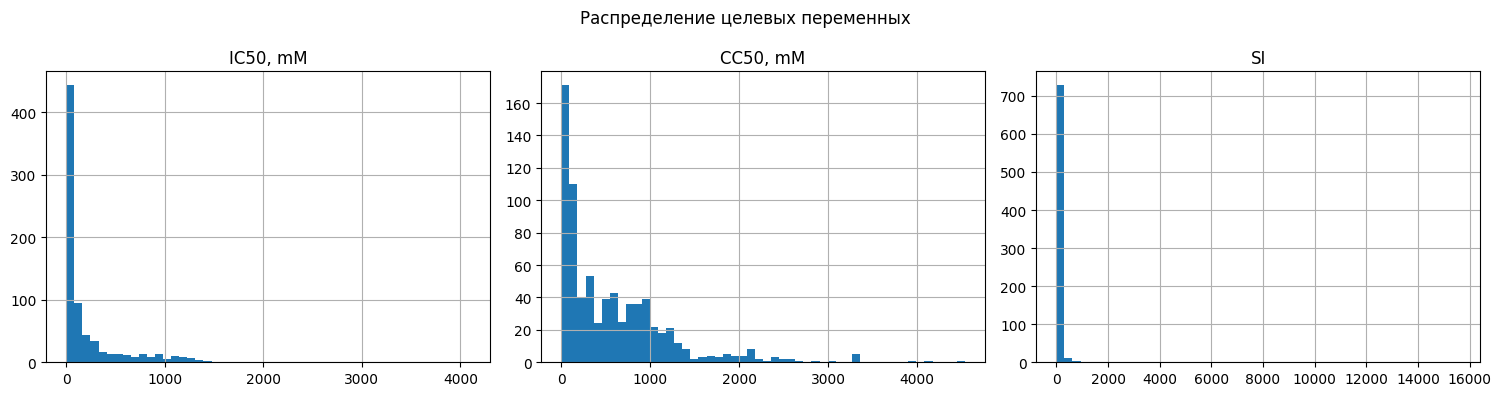

In [11]:
# Распределение целевых переменных
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

train['IC50, mM'].hist(ax=axes[0], bins=50)
axes[0].set_title('IC50, mM')

train['CC50, mM'].hist(ax=axes[1], bins=50)
axes[1].set_title('CC50, mM')

train['SI'].hist(ax=axes[2], bins=50)
axes[2].set_title('SI')

plt.suptitle('Распределение целевых переменных')
plt.tight_layout()
plt.show()

Видно что все три целевых переменных имеют правостороннее распределение с выбросами. Предлагаю обработать их по 99% перцентелю с преобразованием в корень - это даст меньший разброс данных и большую точность модели.

In [12]:
# Обработка выбросов в целевых переменных с защитой от пропусков (NaN)
y_ic50_raw = train['IC50, mM'].values.astype(np.float64)
y_cc50_raw = train['CC50, mM'].values.astype(np.float64)
y_si_raw   = train['SI'].values.astype(np.float64)

# ИСКУССТВЕННЫЙ ФИКС: используем nanpercentile вместо percentile
ic50_p99 = np.nanpercentile(y_ic50_raw, 99)
cc50_p99 = np.nanpercentile(y_cc50_raw, 99)
si_p95 = np.nanpercentile(y_si_raw, 95)

# Трансформация таргетов
y_ic50 = np.sqrt(np.clip(y_ic50_raw, 0, ic50_p99))
y_cc50 = np.sqrt(np.clip(y_cc50_raw, 0, cc50_p99))
y_si   = np.log1p(np.clip(y_si_raw, 0, si_p95))

print(f"99% перцентиль — IC50: {ic50_p99:.1f}, CC50: {cc50_p99:.1f}")
print(f"95% перцентиль — SI:   {si_p95:.1f}")

99% перцентиль — IC50: 1334.3, CC50: 3162.0
95% перцентиль — SI:   138.4


In [13]:
# 1. Заполняем пропуски медианой, чтобы правильно посчитать дисперсию
X_train = X_train.fillna(X_train.median())
test_filled = test.drop(columns=['index'], errors='ignore').fillna(X_train.median())

# 2. Находим признаки с низкой дисперсией
var_series = X_train.var().sort_values()
low_var_cols = var_series[var_series < 0.001].index.tolist()

# 3. Синхронно удаляем их из ОБОИХ датасетов
X_train = X_train.drop(low_var_cols, axis=1)
# Перезаписываем тестовый датасет, оставляя в нем только те же колонки, что и в X_train
test_clean_features = test_filled[X_train.columns]

print(f"Удалено признаков с низкой дисперсией: {len(low_var_cols)}")
print(f"Осталось признаков в трейне: {X_train.shape[1]}")


Удалено признаков с низкой дисперсией: 18
Осталось признаков в трейне: 192


In [14]:
# Feature engineering — логарифмы и правильные отношения признаков
feat_base = X_train.columns.tolist()

# Создаем копию очищенного теста с предыдущего шага
X_test_df = test_clean_features.copy()

# 1. Генерируем логарифмы для строго положительных признаков
for c in feat_base:
    if X_train[c].min() > 0:
        X_train[f"log_{c}"] = np.log1p(X_train[c])
        X_test_df[f"log_{c}"] = np.log1p(X_test_df[c])

# 2. ИСПРАВЛЕНИЕ: Берем реальные Топ-12 признаков по корреляции Спирмена
real_top12 = corr_df["признак"].head(12).tolist()
# Защита: оставляем только те фичи из топ-12, которые не удалились по дисперсии
real_top12 = [c for c in real_top12 if c in feat_base]

# 3. Генерируем математические отношения между ними
for i in range(len(real_top12)):
    for j in range(i+1, len(real_top12)):
        col_name = f"r_{i}_{j}"
        X_train[col_name] = X_train[real_top12[i]] / (X_train[real_top12[j]] + 1e-8)
        X_test_df[col_name]  = X_test_df[real_top12[i]]  / (X_test_df[real_top12[j]]  + 1e-8)

print(f"Итоговых признаков в Train: {X_train.shape[1]}")
print(f"Итоговых признаков в Test: {X_test_df.shape[1]}")

# 4. Переводим в чистые numpy матрицы без бесконечностей и NaN
X      = np.nan_to_num(X_train.values.astype(np.float64), nan=0, posinf=0, neginf=0)
X_test = np.nan_to_num(X_test_df[X_train.columns].values.astype(np.float64), nan=0, posinf=0, neginf=0)

print("Матрицы X и X_test для обучения успешно сформированы!")

Итоговых признаков в Train: 299
Итоговых признаков в Test: 299
Матрицы X и X_test для обучения успешно сформированы!


In [15]:
# Параметры для IC50
cat_p_ic50 = {
    'iterations': 1500,
    'learning_rate': 0.04935,
    'depth': 6,
    'l2_leaf_reg': 8,
    'subsample': 0.6538,
    'min_data_in_leaf': 23,
    'random_seed': 42,
    'verbose': 100,
    'early_stopping_rounds': 200,
    'loss_function': 'RMSE',
    'eval_metric': 'RMSE',
    'use_best_model': True,
}

# Параметры для CC50
cat_p_cc50 = {
    'iterations': 3000,
    'learning_rate': 0.01621,
    'depth': 7,
    'l2_leaf_reg': 1,
    'subsample': 0.7138,
    'min_data_in_leaf': 12,
    'random_seed': 42,
    'verbose': 100,
    'early_stopping_rounds': 200,
    'loss_function': 'RMSE',
    'eval_metric': 'RMSE',
    'use_best_model': True,
}

# Параметры для SI
cat_p_si = {
    'iterations': 3000,
    'learning_rate': 0.01049,
    'depth': 7,
    'l2_leaf_reg': 8,
    'subsample': 0.8340,
    'min_data_in_leaf': 21,
    'random_seed': 42,
    'verbose': 100,
    'early_stopping_rounds': 200,
    'loss_function': 'RMSE',
    'eval_metric': 'RMSE',
    'use_best_model': True,
}

In [20]:
lgb_params_ic50 = {
    'n_estimators': 2000,
    'learning_rate': 0.0218,
    'max_depth': 4,
    'num_leaves': 8,
    'min_child_samples': 22,
    'subsample': 0.6979,
    'colsample_bytree': 0.7965,
    'reg_alpha': 0.0272,
    'reg_lambda': 0.6750,
    'random_state': 42,
    'verbose': -1,
}

lgb_params_cc50 = {
    'n_estimators': 2700,
    'learning_rate': 0.0188,
    'max_depth': 3,
    'num_leaves': 28,
    'min_child_samples': 16,
    'subsample': 0.8190,
    'colsample_bytree': 0.8867,
    'reg_alpha': 0.6072,
    'reg_lambda': 0.6881,
    'random_state': 42,
    'verbose': -1,
}

lgb_params_si = {
    'n_estimators': 2900,
    'learning_rate': 0.0244,
    'max_depth': 4,
    'num_leaves': 9,
    'min_child_samples': 19,
    'subsample': 0.7085,
    'colsample_bytree': 0.6803,
    'reg_alpha': 0.3925,
    'reg_lambda': 0.6689,
    'random_state': 42,
    'verbose': -1,
}

In [17]:
# Восстанавливаем оригинальные названия признаков из кода коллег
X_train_df = pd.DataFrame(X, columns=X_train.columns)
X_test_df = pd.DataFrame(X_test, columns=X_train.columns)

fr_cols = [c for c in X_train_df.columns if c.startswith('fr_')]

# Логарифмируем опорные таргеты для кодирования
target_ic50_enc = np.log1p(y_ic50_raw)
target_cc50_enc = np.log1p(y_cc50_raw)

# Создаем две разные матрицы: одну под IC50, вторую под CC50
X_train_enc_ic = X_train_df.copy()
X_test_enc_ic = X_test_df.copy()

X_train_enc_cc = X_train_df.copy()
X_test_enc_cc = X_test_df.copy()

# Оптимальный вес сглаживания для маленького датасета
smoothing_weight = 4
mean_ic50 = target_ic50_enc.mean()
mean_cc50 = target_cc50_enc.mean()

# Запускаем раздельное кодирование фрагментов
for col in fr_cols:
    # 1. Кодируем для Эффективности (IC50)
    stats_ic = pd.DataFrame({'feat_val': X_train_df[col], 'target': target_ic50_enc})
    grp_ic = stats_ic.groupby('feat_val')['target'].agg(['count', 'mean'])
    map_ic = ((grp_ic['count'] * grp_ic['mean'] + smoothing_weight * mean_ic50) / (grp_ic['count'] + smoothing_weight)).to_dict()
    X_train_enc_ic[col] = X_train_enc_ic[col].map(map_ic).fillna(mean_ic50)
    X_test_enc_ic[col] = X_test_enc_ic[col].map(map_ic).fillna(mean_ic50)

    # 2. Кодируем для Токсичности (CC50)
    stats_cc = pd.DataFrame({'feat_val': X_train_df[col], 'target': target_cc50_enc})
    grp_cc = stats_cc.groupby('feat_val')['target'].agg(['count', 'mean'])
    map_cc = ((grp_cc['count'] * grp_cc['mean'] + smoothing_weight * mean_cc50) / (grp_cc['count'] + smoothing_weight)).to_dict()
    X_train_enc_cc[col] = X_train_enc_cc[col].map(map_cc).fillna(mean_cc50)
    X_test_enc_cc[col] = X_test_enc_cc[col].map(map_cc).fillna(mean_cc50)

print("Dual-Target Encoding успешно завершен!")

# Переводим в массивы numpy
X_enc_ic = X_train_enc_ic.values
X_test_enc_ic = X_test_enc_ic.values

X_enc_cc = X_train_enc_cc.values
X_test_enc_cc = X_test_enc_cc.values

# Таргеты в масштабах команды (корень и лог)
y_ic50_trans = np.sqrt(y_ic50_raw)
y_cc50_trans = np.sqrt(y_cc50_raw)
y_si_trans   = np.log1p(y_si_raw)


Dual-Target Encoding успешно завершен!


In [ ]:
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import KFold

print("Запуск модифицированного пайплайна: Dual-Target Encoding + Блендинг...\n")

N = 5
kf = KFold(n_splits=N, shuffle=True, random_state=42)

pred_ic50_trans = np.zeros(len(X_test))
pred_cc50_trans = np.zeros(len(X_test))
pred_si_trans   = np.zeros(len(X_test))

for fold, (tr, val) in enumerate(kf.split(X), 1):

    m_cb_ic = CatBoostRegressor(**cat_p_ic50)
    m_cb_ic.fit(X_enc_ic[tr], y_ic50_trans[tr], eval_set=(X_enc_ic[val], y_ic50_trans[val]), use_best_model=True)
    m_lgb_ic = LGBMRegressor(**lgb_params_ic50)
    m_lgb_ic.fit(X_enc_ic[tr], y_ic50_trans[tr])
    pred_ic50_trans += (0.70 * m_cb_ic.predict(X_test_enc_ic) + 0.30 * m_lgb_ic.predict(X_test_enc_ic)) / N

    m_cb_cc = CatBoostRegressor(**cat_p_cc50)
    m_cb_cc.fit(X_enc_cc[tr], y_cc50_trans[tr], eval_set=(X_enc_cc[val], y_cc50_trans[val]), use_best_model=True)
    m_lgb_cc = LGBMRegressor(**lgb_params_cc50)
    m_lgb_cc.fit(X_enc_cc[tr], y_cc50_trans[tr])
    pred_cc50_trans += (0.70 * m_cb_cc.predict(X_test_enc_cc) + 0.30 * m_lgb_cc.predict(X_test_enc_cc)) / N

    m_cb_si = CatBoostRegressor(**cat_p_si)
    m_cb_si.fit(X_enc_ic[tr], y_si_trans[tr], eval_set=(X_enc_ic[val], y_si_trans[val]), use_best_model=True)
    m_lgb_si = LGBMRegressor(**lgb_params_si)
    m_lgb_si.fit(X_enc_ic[tr], y_si_trans[tr])
    pred_si_trans += (0.70 * m_cb_si.predict(X_test_enc_ic) + 0.30 * m_lgb_si.predict(X_test_enc_ic)) / N
    print(f"Фолд {fold} из {N} успешно рассчитан.")

# Математически точный обратный перевод
t_ic50 = np.clip(pred_ic50_trans, 0, None) ** 2
t_cc50 = np.clip(pred_cc50_trans, 0, None) ** 2
t_si   = np.expm1(np.clip(pred_si_trans, 0, None))

# Защитный клиппинг по перцентилям твоей команды
t_ic50 = np.clip(t_ic50, 0, ic50_p99)
t_cc50 = np.clip(t_cc50, 0, cc50_p99)
t_si   = np.clip(t_si,   0, si_p95)

# Формируем итоговый DataFrame
submission_dual = pd.DataFrame({
    "index": test["index"],
    "IC50": t_ic50,
    "CC50": t_cc50,
    "SI": t_si
})

submission_dual.to_csv('submission18.csv', index=False)

🔥 Запуск модифицированного пайплайна: Dual-Target Encoding + Блендинг...

0:	learn: 9.5951272	test: 9.8371514	best: 9.8371514 (0)	total: 5.68ms	remaining: 8.52s
100:	learn: 6.4941566	test: 8.7558443	best: 8.7558443 (100)	total: 611ms	remaining: 8.47s
200:	learn: 5.4721114	test: 8.6933739	best: 8.6842608 (188)	total: 1.19s	remaining: 7.71s
300:	learn: 4.7132423	test: 8.6354099	best: 8.6330362 (299)	total: 1.74s	remaining: 6.95s
400:	learn: 4.2015044	test: 8.6375499	best: 8.6297510 (302)	total: 2.31s	remaining: 6.32s
500:	learn: 3.7987230	test: 8.6650966	best: 8.6297510 (302)	total: 2.86s	remaining: 5.7s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 8.629751023
bestIteration = 302

Shrink model to first 303 iterations.
0:	learn: 12.7324539	test: 11.7658304	best: 11.7658304 (0)	total: 12ms	remaining: 35.9s
100:	learn: 8.7514306	test: 9.4884890	best: 9.4884890 (100)	total: 1.15s	remaining: 33.1s
200:	learn: 7.3885314	test: 8.8627825	best: 8.8603462 (199)	total: 2.19s	r

In [ ]:
import optuna
from optuna.samplers import TPESampler
import lightgbm as lgb

def objective_lgb(trial, X, y, cv_folds=3):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 3000, step=100),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.05, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'num_leaves': trial.suggest_int('num_leaves', 8, 64),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 30),
        'subsample': trial.suggest_float('subsample', 0.6, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.9),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0),
        'random_state': 42,
        'verbose': -1,
    }
    
    kf = KFold(n_splits=cv_folds, shuffle=True, random_state=42)
    scores = []
    
    for tr_idx, val_idx in kf.split(X):
        X_tr, X_val = X[tr_idx], X[val_idx]
        y_tr, y_val = y[tr_idx], y[val_idx]
        
        model = lgb.LGBMRegressor(**params)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            eval_metric='rmse',
            callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)]
        )
        
        pred = model.predict(X_val)
        scores.append(np.sqrt(mean_squared_error(y_val, pred)))
    
    return np.mean(scores)

# Оптимизация для IC50
print("Оптимизация LightGBM для IC50...")
study_lgb_ic50 = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
study_lgb_ic50.optimize(
    lambda trial: objective_lgb(trial, X_enc_ic, y_ic50_trans, cv_folds=3),
    n_trials=30,
    show_progress_bar=True
)

print("\nЛучшие параметры LightGBM для IC50:")
print(f"   Score: {study_lgb_ic50.best_value:.4f}")
for key, value in study_lgb_ic50.best_params.items():
    print(f"   {key}: {value}")

# Оптимизация для CC50
print("\nОптимизация LightGBM для CC50...")
study_lgb_cc50 = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
study_lgb_cc50.optimize(
    lambda trial: objective_lgb(trial, X_enc_cc, y_cc50_trans, cv_folds=3),
    n_trials=30,
    show_progress_bar=True
)

print("\nЛучшие параметры LightGBM для CC50:")
print(f"   Score: {study_lgb_cc50.best_value:.4f}")
for key, value in study_lgb_cc50.best_params.items():
    print(f"   {key}: {value}")

# Оптимизация для SI
print("\nОптимизация LightGBM для SI...")
study_lgb_si = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
study_lgb_si.optimize(
    lambda trial: objective_lgb(trial, X_enc_ic, y_si_trans, cv_folds=3),
    n_trials=30,
    show_progress_bar=True
)

print("\nЛучшие параметры LightGBM для SI:")
print(f"   Score: {study_lgb_si.best_value:.4f}")
for key, value in study_lgb_si.best_params.items():
    print(f"   {key}: {value}")

[I 2026-05-23 15:26:32,544] A new study created in memory with name: no-name-ec5f61f9-45a8-4cac-b57e-5070d049144d


Оптимизация LightGBM для IC50...


  0%|          | 0/30 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[54]	valid_0's rmse: 7.89076	valid_0's l2: 62.2641
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[42]	valid_0's rmse: 8.31124	valid_0's l2: 69.0768
Training until validation scores don't improve for 50 rounds


Best trial: 0. Best value: 8.11562:   3%|▎         | 1/30 [00:00<00:07,  3.86it/s]

...

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[119]	valid_0's rmse: 1.1864	valid_0's l2: 1.40754
Training until validation scores don't improve for 50 rounds


Best trial: 10. Best value: 1.24883:  97%|█████████▋| 29/30 [00:13<00:00,  2.43it/s]

Early stopping, best iteration is:
[215]	valid_0's rmse: 1.3269	valid_0's l2: 1.76066
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[204]	valid_0's rmse: 1.27184	valid_0's l2: 1.61757
[I 2026-05-23 15:27:16,129] Trial 28 finished with value: 1.261712374314568 and parameters: {'n_estimators': 2400, 'learning_rate': 0.018635733503732686, 'max_depth': 6, 'num_leaves': 21, 'min_child_samples': 17, 'subsample': 0.7639302223147227, 'colsample_bytree': 0.7264880195434388, 'reg_alpha': 0.29929067687184907, 'reg_lambda': 0.6235751420575126}. Best is trial 10 with value: 1.2488279523073886.
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[83]	valid_0's rmse: 1.20594	valid_0's l2: 1.45428
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[300]	valid_0's rmse: 1.32405	valid_0's l2: 1.75311
Training until validation scores don't improve for 50 rounds
Early 

Best trial: 10. Best value: 1.24883: 100%|██████████| 30/30 [00:14<00:00,  2.11it/s]

[I 2026-05-23 15:27:16,402] Trial 29 finished with value: 1.265096306476318 and parameters: {'n_estimators': 2800, 'learning_rate': 0.03579555805901442, 'max_depth': 4, 'num_leaves': 13, 'min_child_samples': 27, 'subsample': 0.8020636938373742, 'colsample_bytree': 0.7636575419259374, 'reg_alpha': 0.22944279300706732, 'reg_lambda': 0.5757991060427068}. Best is trial 10 with value: 1.2488279523073886.

✅ Лучшие параметры LightGBM для SI:
   Score: 1.2488
   n_estimators: 2900
   learning_rate: 0.024432992330650632
   max_depth: 4
   num_leaves: 9
   min_child_samples: 19
   subsample: 0.7085302698115487
   colsample_bytree: 0.6803048066137114
   reg_alpha: 0.3924528921026324
   reg_lambda: 0.668924407059101
